### Importing packages

In [1]:
import os
import torchvision.models.segmentation as models
import torch
import torch.nn as nn
import cv2
import glob
import numpy as np
import torch
from os.path import isfile, join
import matplotlib.pyplot as plt 
from PIL import Image
from torchvision import transforms as T

### Torch model

In [2]:
pretrained_model = models.deeplabv3_resnet50(pretrained=True)
pretrained_model.eval()
class CustomModel(nn.Module):
    def __init__(self,pretrained_model):
        super(CustomModel,self).__init__()
        self.pretrained_model = pretrained_model
        self.argmax = nn.LogSoftmax(dim=1)
    def forward(self,x):
        output_dict = self.pretrained_model(x)
        output = output_dict['out']
        argmax_output = torch.argmax(output,dim=1,keepdim=False)
        return argmax_output
model = CustomModel(pretrained_model)
input = torch.randn(1,3,288,512)
output = model(input)
output.shape

c:\ashwath\envs\python3.8_acer_notebooks\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\ashwath\envs\python3.8_acer_notebooks\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


torch.Size([1, 288, 512])

### Save onnx 

In [3]:
import os
dummy_input = torch.randn(1,3, 288, 512).type(torch.FloatTensor).to('cpu')
torch.onnx.export(model, dummy_input, "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\deeplabv3_resnet50.onnx",opset_version=11)

### Preprocess

In [4]:
import PIL.Image as pil
from torchvision import transforms as T
transform = T.Compose([
                T.Resize((288,512)),
                
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225]),
            ])
image_path = 'C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\blur_0.jpg'   # change input path

# Load image and preprocess
feed_width = 512
feed_height = 288
input_image = pil.open(image_path).convert('RGB')
original_width, original_height = input_image.size

input_image_resize = input_image.resize((feed_width, feed_height), pil.LANCZOS)
input_image_transform = transform(input_image_resize).unsqueeze(0)
print(input_image_transform.shape)
input_image_transform.detach().cpu().numpy().transpose(0,2,3,1).astype(np.float32).tofile(f"assets/input.raw")

torch.Size([1, 3, 288, 512])


In [5]:
os.environ['QNN_ROOT']="C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401"
os.environ['PYTHONPATH']= "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\\lib\\python"
os.environ['PATH']=os.environ['PATH']+"C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\\bin\\aarch64-windows-msvc"

### Save raw path to input list

In [6]:
with open("assets/input_list.txt","w") as file:
    for raw in os.listdir("assets/"):
        if ".raw" in raw:
            file.write(raw)

##### Copy all files from bin\arm64x-windows-msvc,  lib\arm64x-windows-msvc and lib\hexagon-v73\unsigned to Current directory

In [7]:
import shutil
SDK_dir = "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401"       # Specify what's QNN SDK used
SDK_lib_dir = SDK_dir + "\\lib\\arm64x-windows-msvc"
SDK_skel = SDK_dir + "\\lib\\hexagon-v73\\unsigned"

# Copy necessary libraries to a common location
libs = ["QnnCpu.dll","QnnHtp.dll", "QnnSystem.dll", "QnnHtpNetRunExtensions.dll", "QnnHtpPrepare.dll", "QnnHtpV73Stub.dll"]
for lib in libs:
    shutil.copy(SDK_lib_dir + "\\" + lib, "assets")
skel_libs = ["libqnnhtpv73.cat", "libQnnHtpV73.so", "libQnnHtpV73Skel.so"]
# Copy Skel
for lib in skel_libs:
    shutil.copy(SDK_skel + "\\" + lib, "assets")

### Convert onnx to .cpp and .bin

In [8]:
%%cmd
cd assets
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\deeplabv3_resnet50.onnx" -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\deeplabv3_resnet50.cpp"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd assets

C:\Qualcomm\AIStack\models\Background_Blur\assets>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\deeplabv3_resnet50.onnx" -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\deeplabv3_resnet50.cpp"


2024-06-14 23:35:32,984 - 235 - INFO - Skipping quantization, no input_list provided
2024-06-14 23:35:32,984 - 235 - INFO - Saving QNN Model...
2024-06-14 23:35:33,220 - 235 - INFO - Model CPP saved at: C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\deeplabv3_resnet50.cpp 
2024-06-14 23:35:33,220 - 235 - INFO - Model BIN saved at: C:\Qualcomm\AIStack\models\Background_Blur\assets\float32\deeplabv3_resnet50.bin 
2024-06-14 23:35:33,274 - 235 - INFO - Conversion complete!



C:\Qualcomm\AIStack\models\Background_Blur\assets>

In [ ]:
'''
[NOT TESTED]
If you want to convert the model to int16 instead of int8, please use the following command in the cell below: 
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" ^
    -i "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\deeplabv3_resnet50.onnx" ^
    --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\deeplabv3_resnet50.cpp" ^
    --act_bw 16 --weight_bw 16 --bias_bw 8
'''

In [9]:
%%cmd
cd assets
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\deeplabv3_resnet50.onnx" --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\deeplabv3_resnet50.cpp"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd assets

C:\Qualcomm\AIStack\models\Background_Blur\assets>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\deeplabv3_resnet50.onnx" --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\deeplabv3_resnet50.cpp"


2024-06-14 23:37:15,606 - 235 - INFO - Saving QNN Model...
2024-06-14 23:37:15,684 - 235 - INFO - Model CPP saved at: C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\deeplabv3_resnet50.cpp 
2024-06-14 23:37:15,684 - 235 - INFO - Model BIN saved at: C:\Qualcomm\AIStack\models\Background_Blur\assets\int8\deeplabv3_resnet50.bin 
2024-06-14 23:37:15,699 - 235 - INFO - Conversion complete!


     3.7ms [  INFO ] Inferences will run in sync mode
    24.7ms [  INFO ] Initializing logging in the backend. Callback: [00007FFDC4157810], Log Level: [3]
    24.7ms [  INFO ] No BackendExtensions lib provided;initializing NetRunBackend Interface
    24.8ms [WARNING] Unable to find a device with NetRunDeviceKeyDefault in Library NetRunBackendLibKeyDefault
    24.9ms [  INFO ] Entering QuantizeRuntimeApp flow
   342.2ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::finalize
   370.9ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::execute
  2060.7ms [  INFO ] cleaning up resources for input tensors
  2060.9ms [  INFO ] cleaning up resources for output tensors
  2151.8ms [  INFO ] Freeing graphsInfo

C:\Qualcomm\AIStack\models\Background_Blur\assets>

In [10]:
%%cmd
mkdir "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>mkdir "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs"

C:\Qualcomm\AIStack\models\Background_Blur>

### Generate model.dll 

In [11]:
%%cmd
cd assets
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\deeplabv3_resnet50.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\deeplabv3_resnet50.bin" -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\float32" -t windows-aarch64 

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd assets

C:\Qualcomm\AIStack\models\Background_Blur\assets>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\deeplabv3_resnet50.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\deeplabv3_resnet50.bin" -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\float32" -t windows-aarch64 


2024-06-14 23:37:45,683 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\deeplabv3_resnet50.cpp
2024-06-14 23:37:45,683 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\deeplabv3_resnet50.bin
2024-06-14 23:37:45,683 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-06-14 23:37:45,683 -    INFO - qnn-model-lib-generator: Library name         : None
2024-06-14 23:37:45,683 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\float32
2024-06-14 23:37:45,683 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-06-14 23:37:45,683 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-06-14 23:37:45,683 -    INFO - qnn-model-lib-generator: Output library name  : deeplabv3_resnet50.dll
2024-06-14 23:


C:\Qualcomm\AIStack\models\Background_Blur\assets>

In [12]:
%%cmd
cd assets
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\deeplabv3_resnet50.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\deeplabv3_resnet50.bin" -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\int8" -t  windows-aarch64

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd assets

C:\Qualcomm\AIStack\models\Background_Blur\assets>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\deeplabv3_resnet50.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\deeplabv3_resnet50.bin" -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\int8" -t  windows-aarch64


2024-06-14 23:38:52,251 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\deeplabv3_resnet50.cpp
2024-06-14 23:38:52,251 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\deeplabv3_resnet50.bin
2024-06-14 23:38:52,251 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-06-14 23:38:52,251 -    INFO - qnn-model-lib-generator: Library name         : None
2024-06-14 23:38:52,251 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\int8
2024-06-14 23:38:52,251 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-06-14 23:38:52,251 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-06-14 23:38:52,251 -    INFO - qnn-model-lib-generator: Output library name  : deeplabv3_resnet50.dll
2024-06-14 23:38:52,467


C:\Qualcomm\AIStack\models\Background_Blur\assets>

### Generate serialized binary

In [13]:
json_str = """{
    "graphs": {
        "vtcm_mb":8,
        "graph_names":[],
        "O":3.0
    },
    "devices": [
        {
            "soc_id": 60,
            "dsp_arch": "v73",
            "cores":[{
                "core_id": 0,
                "perf_profile": "burst",
                "rpc_control_latency":100
            }]
        }
    ]
}"""
f = open(".\\assets\\htp_backend_extensions.json", "w")
f.write(json_str)
f.close()

In [14]:
%%cmd
cd assets
qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\int8\ARM64\deeplabv3_resnet50.dll" ^
    --backend "QnnHtp.dll" --binary_file deeplabv3_resnet50.serialized ^
    --config_file "htp_backend_extensions.json"
move  output\deeplabv3_resnet50.serialized.bin "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\deeplabv3_resnet50.serialized.bin"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd assets

C:\Qualcomm\AIStack\models\Background_Blur\assets>qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\int8\ARM64\deeplabv3_resnet50.dll" ^
More?     --backend "QnnHtp.dll" --binary_file deeplabv3_resnet50.serialized ^
More?     --config_file "htp_backend_extensions.json"
qnn-context-binary-generator pid:14976
Starting stage: Graph Preparation Initializing
Completed stage: Graph Preparation Initializing (219 us)
Starting stage: Graph Transformations and Optimizations
Completed stage: Graph Transformations and Optimizations (285629 us)
Starting stage: Graph Sequencing for Target
 [##################################################] 100%
Completed stage: Graph Sequencing for Target (1243305 us)
Starting stage: VTCM Allocation
Completed stage: VTCM Allocation (277000 us)
Starting stage: Parall

In [15]:
%%cmd 
cd assets
rmdir /s  output_cpu
Y
rmdir /s  output_dsp 
Y

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd assets

C:\Qualcomm\AIStack\models\Background_Blur\assets>rmdir /s  output_cpu
output_cpu, Are you sure (Y/N)? Y


The system cannot find the file specified.
The system cannot find the file specified.



C:\Qualcomm\AIStack\models\Background_Blur\assets>rmdir /s  output_dsp 
output_dsp, Are you sure (Y/N)? Y

C:\Qualcomm\AIStack\models\Background_Blur\assets>

### Execution on CPU

In [16]:
%%cmd
cd assets
qnn-net-run --model "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\float32\ARM64\deeplabv3_resnet50.dll" --input_list input_list.txt --backend QnnCpu.dll --output_dir output_cpu --perf_profile sustained_high_performance  --profiling_level basic

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd assets

C:\Qualcomm\AIStack\models\Background_Blur\assets>qnn-net-run --model "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\float32\ARM64\deeplabv3_resnet50.dll" --input_list input_list.txt --backend QnnCpu.dll --output_dir output_cpu --perf_profile sustained_high_performance  --profiling_level basic
qnn-net-run pid:7016

C:\Qualcomm\AIStack\models\Background_Blur\assets>

### Execution on HTP

In [17]:
%%cmd
cd assets
qnn-net-run --retrieve_context "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\deeplabv3_resnet50.serialized.bin" --input_list input_list.txt --backend QnnHtp.dll --output_dir output_dsp --perf_profile sustained_high_performance  --profiling_level basic

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd assets

C:\Qualcomm\AIStack\models\Background_Blur\assets>qnn-net-run --retrieve_context "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\deeplabv3_resnet50.serialized.bin" --input_list input_list.txt --backend QnnHtp.dll --output_dir output_dsp --perf_profile sustained_high_performance  --profiling_level basic
qnn-net-run pid:6960

C:\Qualcomm\AIStack\models\Background_Blur\assets>

### PostProcess

In [18]:
label_map = [
               (0, 0, 0),  # background
               (127, 0, 0), # aeroplane
               (0, 128, 0), # bicycle
               (128, 128, 0), # bird
               (0, 0, 128), # boat
               (128, 0, 128), # bottle
               (0, 128, 128), # bus 
               (126, 126, 126), # car
               (64, 0, 0), # cat
               (192, 0, 0), # chair
               (64, 128, 0), # cow
               (192, 128, 0), # dining table
               (64, 0, 128), # dog
               (192, 0, 128), # horse
               (64, 128, 128), # motorbike
               (128, 128, 128), # person
               (0, 64, 0), # potted plant
               (128, 64, 0), # sheep
               (0, 192, 0), # sofa
               (128, 192, 0), # train
               (0, 64, 128) # tv/monitor
]
import time
def image_overlay(image, segmented_image):    
    kernel_size = 15 # change based on blur required
    segmented_image_x = np.where(segmented_image == 128)
    image_blur = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0) 
    image_blur[segmented_image_x] = image[segmented_image_x]

    return image_blur

def get_segment_labels(image, model, device):
    image = transform(image).to(device)
    image = image.unsqueeze(0)
    outputs = model(image)
    return outputs

def draw_segmentation_map(outputs):
    labels = outputs.detach().cpu().numpy()
    red_map = np.zeros_like(labels).astype(np.uint8)
    green_map = np.zeros_like(labels).astype(np.uint8)
    blue_map = np.zeros_like(labels).astype(np.uint8)
    
    for label_num in range(0, len(label_map)):
        index = labels == label_num
        red_map[index] = np.array(label_map)[label_num, 0]
        green_map[index] = np.array(label_map)[label_num, 1]
        blue_map[index] = np.array(label_map)[label_num, 2]
        
    segmentation_map = np.stack([red_map, green_map, blue_map], axis=2)
    return segmentation_map


In [19]:
import torch.nn.functional as F
from torchvision.utils import save_image
from torch import from_numpy
from matplotlib.image import imread

def postprocess(path):
    image_path = 'C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\blur_0.jpg'   # change input path
    plt.figure(dpi=100)
    
    f, axarr = plt.subplots(1,3,figsize=(20, 20)) 
    axarr[0].imshow(imread(image_path))
    
    results = []
    for id,OUTPUT in enumerate(path):
        for target,result in enumerate(os.listdir(OUTPUT)):
            if "log" not in result:
                edge_maps = []
                for raw in ["_597.raw"]:
                    bok_pred = np.fromfile(OUTPUT+result+"/"+raw,dtype="float32").reshape(1,288,512)
                    bok_pred = torch.from_numpy(bok_pred)
                    input_image_org = cv2.imread(image_path)
                    
                    segmented_image = draw_segmentation_map(bok_pred[0])
                    h,w = input_image_org.shape[:2]
                    input_image  = cv2.resize(input_image_org,(512,288))
                    final_image = image_overlay(input_image, segmented_image)
                    
                    final_image = cv2.resize(final_image ,(w,h))
                    cv2.imwrite(OUTPUT[:-1]+'.png',final_image)
                    axarr[id+1].imshow(imread(OUTPUT[:-1]+'.png'))
    
    axarr[0].title.set_text('Input image')
    axarr[1].title.set_text('CPU')
    axarr[2].title.set_text('HTP')



<Figure size 640x480 with 0 Axes>

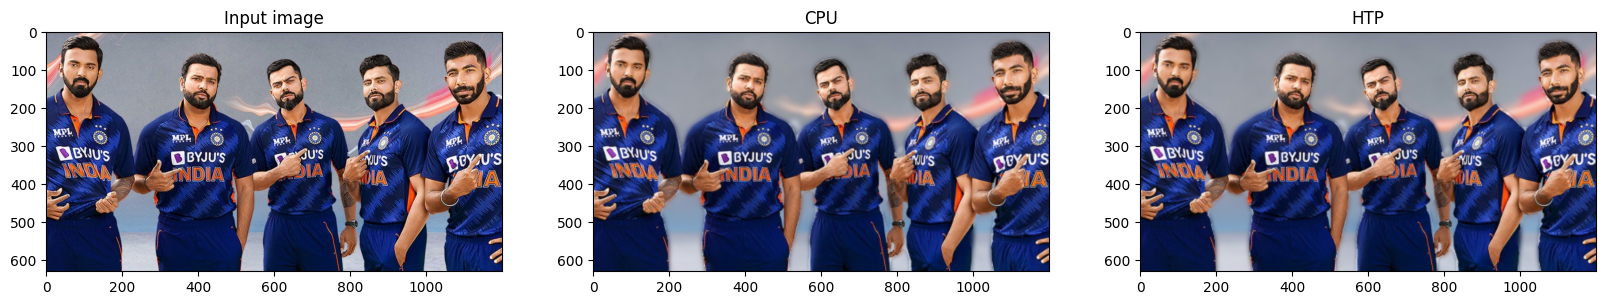

In [20]:
postprocess(["assets/output_cpu/","assets/output_dsp/"])

In [21]:
%%cmd
cd assets
qnn-profile-viewer --input_log output_dsp/qnn-profiling-data_0.log


Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd assets

C:\Qualcomm\AIStack\models\Background_Blur\assets>qnn-profile-viewer --input_log output_dsp/qnn-profiling-data_0.log
Log File Created: Fri Jun 14 23:41:41 2024
Time Scale: 1e-06
Epoch Timestamp: 1718433701395866 Steady Clock Timestamp: 906708270856
Generated using: 
qnn-profile-viewer v2.21.0.240401120655_85612
qnn-net-run        v2.21.0.240401120655_85612
Backend            v2.21.0.240401120655_85612

Qnn Init/Prepare/Finalize/De-Init/Execute/Lib-Load Statistics:
------------------------------------------------------------
Init Stats:
-----------
    NetRun: 30034 us
    Backend (RPC (load binary) time): 16341 us
    Backend (QNN accelerator (load binary) time): 15857 us
    Backend (Accelerator (load binary) time): 15311 us
    Backend (QNN (load binary) time): 30020 us

Compose Graphs Stats:
--------------
    NetRun: 0 us

Finalize Stats